In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("E:\Data analysis projects\cricket_odi_analytics\data\odi_ball_by_ball.csv")

In [3]:
print(df.columns.tolist())

['match_id', 'inning', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_total', 'extras', 'wicket', 'player_out', 'wicket_kind', 'team', 'ball_id', 'is_four', 'is_six', 'dot_ball', 'phase']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639277 entries, 0 to 1639276
Data columns (total 19 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   match_id     1639277 non-null  int64 
 1   inning       1639277 non-null  int64 
 2   over         1639277 non-null  int64 
 3   ball         1639277 non-null  int64 
 4   batter       1639277 non-null  object
 5   bowler       1639277 non-null  object
 6   non_striker  1639277 non-null  object
 7   runs_batter  1639277 non-null  int64 
 8   runs_total   1639277 non-null  int64 
 9   extras       1639277 non-null  int64 
 10  wicket       1639277 non-null  int64 
 11  player_out   44877 non-null    object
 12  wicket_kind  44877 non-null    object
 13  team         1639277 non-null  object
 14  ball_id      1639277 non-null  int64 
 15  is_four      1639277 non-null  int64 
 16  is_six       1639277 non-null  int64 
 17  dot_ball     1639277 non-null  int64 
 18  phase        1639277 n

In [5]:
df.head()

,match_id,inning,over,ball,batter,bowler,non_striker,runs_batter,runs_total,extras,wicket,player_out,wicket_kind,team,ball_id,is_four,is_six,dot_ball,phase
0,1000887,1,0,1,DA Warner,Mohammad Amir,TM Head,0,0,0,0,NaN,NaN,Australia,1,0,0,1,Powerplay
1,1000887,1,0,2,DA Warner,Mohammad Amir,TM Head,0,0,0,0,NaN,NaN,Australia,2,0,0,1,Powerplay
2,1000887,1,0,3,DA Warner,Mohammad Amir,TM Head,0,0,0,0,NaN,NaN,Australia,3,0,0,1,Powerplay
3,1000887,1,0,4,DA Warner,Mohammad Amir,TM Head,0,0,0,0,NaN,NaN,Australia,4,0,0,1,Powerplay
4,1000887,1,0,5,DA Warner,Mohammad Amir,TM Head,0,1,1,0,NaN,NaN,Australia,5,0,0,0,Powerplay


## ``Build Batting Statistics Dataset``

#### Player_team

In [6]:
player_team = df.groupby("batter")["team"].agg(lambda x: x.mode()[0])
player_team.head()

batter
A Aitken-Drummond       Scotland
A Ashok              New Zealand
A Athanaze           West Indies
A Bagai                   Canada
A Balbirnie              Ireland
Name: team, dtype: object

#### Matches played

In [7]:
# matches_played = df.groupby("batter")[["match_id", "inning"]].nunique(dropna=False).sum(axis=1)
matches_played = df.groupby("batter")["match_id"].nunique()
matches_played.head()

batter
A Aitken-Drummond     8
A Ashok               1
A Athanaze           17
A Bagai              24
A Balbirnie          83
Name: match_id, dtype: int64

#### Innings Batted

In [8]:

innings_batted = (
    df.groupby(["batter","match_id","inning"])
      .size()
      .reset_index()
      .groupby("batter")
      .size()
)
innings_batted.head()

batter
A Aitken-Drummond     8
A Ashok               1
A Athanaze           17
A Bagai              24
A Balbirnie          83
dtype: int64

#### Dismissals

In [9]:
dismissals = df[df['player_out'].notna()].groupby('player_out').size()
dismissals.head()

player_out
A Aitken-Drummond     8
A Ashok               1
A Athanaze           17
A Bagai              21
A Balbirnie          79
dtype: int64

#### Not Outs

In [10]:
not_outs = innings_batted - dismissals
not_out = not_outs.fillna(0)
not_outs.head()

A Aitken-Drummond    0.0
A Ashok              0.0
A Athanaze           0.0
A Bagai              3.0
A Balbirnie          4.0
dtype: float64

In [11]:
not_out = not_out.astype('int64')
not_out.head()

A Aitken-Drummond    0
A Ashok              0
A Athanaze           0
A Bagai              3
A Balbirnie          4
dtype: int64

#### Total Runs by Batsman

In [12]:
batting_runs = df.groupby("batter")["runs_batter"].sum()
print(batting_runs.head())

batter
A Aitken-Drummond      78
A Ashok                10
A Athanaze            405
A Bagai               614
A Balbirnie          2628
Name: runs_batter, dtype: int64


### Balls Faced

In [13]:
balls_faced = df.groupby("batter").size()
balls_faced.head()

batter
A Aitken-Drummond     114
A Ashok                12
A Athanaze            537
A Bagai               995
A Balbirnie          3557
dtype: int64

#### Count Fours

In [14]:
fours = df.groupby("batter")["is_four"].sum()
fours.head()

batter
A Aitken-Drummond     13
A Ashok                2
A Athanaze            46
A Bagai               63
A Balbirnie          254
Name: is_four, dtype: int64

#### Count Sixes

In [15]:
sixes = df.groupby("batter")["is_six"].sum()
sixes.head()

batter
A Aitken-Drummond     0
A Ashok               0
A Athanaze            9
A Bagai               1
A Balbirnie          34
Name: is_six, dtype: int64

#### Combine Batting Statistics

In [16]:
batting_stats = pd.DataFrame({
    "team": player_team,
    "matches":matches_played,
    "innings":innings_batted,
    "dismisals":dismissals,
    "not_out":not_outs,
    "runs": batting_runs,
    "balls": balls_faced,
    "fours": fours,
    "sixes": sixes
})

In [17]:
batting_stats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2505 entries, A Aitken-Drummond to Zulqarnain Haider
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   team       2502 non-null   object 
 1   matches    2502 non-null   float64
 2   innings    2502 non-null   float64
 3   dismisals  2388 non-null   float64
 4   not_out    2385 non-null   float64
 5   runs       2502 non-null   float64
 6   balls      2502 non-null   float64
 7   fours      2502 non-null   float64
 8   sixes      2502 non-null   float64
dtypes: float64(8), object(1)
memory usage: 195.7+ KB


In [18]:
batting_stats.isnull().sum()

team           3
matches        3
innings        3
dismisals    117
not_out      120
runs           3
balls          3
fours          3
sixes          3
dtype: int64

In [19]:
batting_stats.head()

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes
A Aitken-Drummond,Scotland,8.0,8.0,8.0,0.0,78.0,114.0,13.0,0.0
A Ashok,New Zealand,1.0,1.0,1.0,0.0,10.0,12.0,2.0,0.0
A Athanaze,West Indies,17.0,17.0,17.0,0.0,405.0,537.0,46.0,9.0
A Bagai,Canada,24.0,24.0,21.0,3.0,614.0,995.0,63.0,1.0
A Balbirnie,Ireland,83.0,83.0,79.0,4.0,2628.0,3557.0,254.0,34.0


In [20]:
batting_stats['dismisals'] = batting_stats['dismisals'].fillna(0)
batting_stats['not_out'] = batting_stats['not_out'].fillna(0)
batting_stats['team'] = batting_stats['team'].fillna('Unknown')
batting_stats['matches'] = batting_stats['matches'].fillna(0)
batting_stats['innings'] = batting_stats['innings'].fillna(0)
batting_stats['runs'] = batting_stats['runs'].fillna(0)
batting_stats['balls'] = batting_stats['balls'].fillna(0)
batting_stats['fours'] = batting_stats['fours'].fillna(0)
batting_stats['sixes'] = batting_stats['sixes'].fillna(0)

In [21]:
int_columns = ['matches', 'innings', 'dismisals', 'not_out', 'runs', 'balls', 'fours', 'sixes']
batting_stats[int_columns] = batting_stats[int_columns].astype(int)

In [22]:
batting_stats.head()

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes
A Aitken-Drummond,Scotland,8,8,8,0,78,114,13,0
A Ashok,New Zealand,1,1,1,0,10,12,2,0
A Athanaze,West Indies,17,17,17,0,405,537,46,9
A Bagai,Canada,24,24,21,3,614,995,63,1
A Balbirnie,Ireland,83,83,79,4,2628,3557,254,34


In [23]:
batting_stats.isnull().sum()

team         0
matches      0
innings      0
dismisals    0
not_out      0
runs         0
balls        0
fours        0
sixes        0
dtype: int64

## `Sort Best Run Scorers`

In [24]:
batting_stats.sort_values("runs", ascending=False).head(10)

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes
V Kohli,India,296,296,251,45,14675,15958,1366,170
KC Sangakkara,Sri Lanka,284,284,252,32,11640,14663,1122,77
RG Sharma,India,270,270,236,34,11357,12532,1069,351
MS Dhoni,India,279,279,200,79,10274,12090,787,210
AB de Villiers,South Africa,213,213,175,38,9435,9488,825,200
TM Dilshan,Sri Lanka,259,259,229,30,9212,10777,1022,50
LRPL Taylor,New Zealand,209,209,174,35,8126,10040,674,133
DPMD Jayawardene,Sri Lanka,264,264,241,23,8069,10269,743,52
HM Amla,South Africa,174,174,161,13,7834,9058,796,49
Tamim Iqbal,Bangladesh,215,215,203,12,7648,9979,841,96


#### Calculate Strike Rate

In [25]:
batting_stats["strike_rate"] = ((batting_stats["runs"] / batting_stats["balls"]) * 100).round(2)
batting_stats.head()

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,strike_rate
A Aitken-Drummond,Scotland,8,8,8,0,78,114,13,0,68.42
A Ashok,New Zealand,1,1,1,0,10,12,2,0,83.33
A Athanaze,West Indies,17,17,17,0,405,537,46,9,75.42
A Bagai,Canada,24,24,21,3,614,995,63,1,61.71
A Balbirnie,Ireland,83,83,79,4,2628,3557,254,34,73.88


## `Sort best strike rate`

In [26]:
# filter
strike_rate_stats_filter = batting_stats[batting_stats["balls"] >= 2000]
strike_rate_stats_filter.sort_values("strike_rate", ascending=False).head(10)

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,strike_rate
Shahid Afridi,Pakistan,185,185,168,17,3913,2987,341,177,131.00
GJ Maxwell,Australia,132,132,116,16,3695,3054,354,138,120.99
JC Buttler,England,168,169,138,31,5473,4839,445,182,113.10
NLTC Perera,Sri Lanka,128,128,114,14,2233,2045,168,83,109.19
TM Head,Australia,74,74,69,5,2948,2860,340,72,103.08
JJ Roy,England,109,109,106,3,4237,4116,509,81,102.94
AC Gilchrist,Australia,118,118,112,6,4355,4260,556,75,102.23
V Sehwag,India,165,165,163,2,5763,5649,769,107,102.02
DA Miller,South Africa,150,150,107,43,4573,4510,341,143,101.40
JM Bairstow,England,95,95,87,8,3671,3682,418,83,99.70


#### Calculate Batting Average

In [27]:
batting_stats["average"] = (batting_stats["runs"] / batting_stats["dismisals"]).round(2)

## `Sort Best average`

In [78]:
# filter
batting_average_filtered = batting_stats[batting_stats["balls"] >= 3000]
batting_average_filtered.sort_values("average", ascending=False).head(10)


,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,50s,100s,highest_score,strike_rate,average
V Kohli,India,296,296,251,45,14675,15958,1366,170,75,54,183,91.96,58.47
M Raj,India,70,70,51,19,2949,4320,298,13,30,2,125,68.26,57.82
MM Lanning,Australia,76,76,63,13,3555,3985,437,29,19,10,152,89.21,56.43
Shubman Gill,India,61,61,53,8,2953,3065,335,63,17,8,208,96.35,55.72
EA Perry,Australia,98,98,66,32,3673,4683,339,47,34,2,107,78.43,55.65
Babar Azam,Pakistan,131,131,115,16,6203,7243,578,65,33,20,158,85.64,53.94
AB de Villiers,South Africa,213,213,175,38,9435,9488,825,200,52,25,176,99.44,53.91
L Wolvaardt,South Africa,116,116,100,16,5230,6994,596,17,36,12,184,74.78,52.30
AE Satterthwaite,New Zealand,66,66,56,10,2895,3618,308,10,18,6,137,80.02,51.70
MS Dhoni,India,279,279,200,79,10274,12090,787,210,72,9,148,84.98,51.37


#### Calculate Runs per Innings

In [29]:
innings_runs = (
    df.groupby(["batter", "match_id", "inning"])["runs_batter"]
      .sum()
      .reset_index()
)
innings_runs.head()

,batter,match_id,inning,runs_batter
0,A Aitken-Drummond,1444544,1,16
1,A Aitken-Drummond,1444545,1,17
2,A Aitken-Drummond,1444547,2,0
3,A Aitken-Drummond,1444548,1,0
4,A Aitken-Drummond,1477010,1,21


#### Calculate 50s

In [30]:
fifties = (
    innings_runs[(innings_runs["runs_batter"] >= 50) &
                 (innings_runs["runs_batter"] < 100)]
    .groupby("batter")
    .size()
)
fifties.head()

batter
A Athanaze      2
A Bagai         5
A Balbirnie    13
A Bosch         2
A Brindle       3
dtype: int64

#### Calculate 100s

In [31]:
hundreds = (
    innings_runs[innings_runs["runs_batter"] >= 100]
    .groupby("batter")
    .size()
)
hundreds.head()

batter
A Balbirnie    8
A Brindle      1
A Dercksen     1
A Flintoff     2
A Gardner      3
dtype: int64

#### Calculate Highest Score

In [32]:
highest_score = (
    innings_runs.groupby("batter")["runs_batter"]
    .max()
)
highest_score.head()

batter
A Aitken-Drummond     22
A Ashok               10
A Athanaze            66
A Bagai               87
A Balbirnie          135
Name: runs_batter, dtype: int64

#### Adding columns to batting_stats

In [33]:
batting_stats["50s"] = fifties
batting_stats["100s"] = hundreds
batting_stats["highest_score"] = highest_score
batting_stats.head()

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,strike_rate,average,50s,100s,highest_score
A Aitken-Drummond,Scotland,8,8,8,0,78,114,13,0,68.42,9.75,NaN,NaN,22.0
A Ashok,New Zealand,1,1,1,0,10,12,2,0,83.33,10.00,NaN,NaN,10.0
A Athanaze,West Indies,17,17,17,0,405,537,46,9,75.42,23.82,2.0,NaN,66.0
A Bagai,Canada,24,24,21,3,614,995,63,1,61.71,29.24,5.0,NaN,87.0
A Balbirnie,Ireland,83,83,79,4,2628,3557,254,34,73.88,33.27,13.0,8.0,135.0


In [34]:
batting_stats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2505 entries, A Aitken-Drummond to Zulqarnain Haider
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   team           2505 non-null   object 
 1   matches        2505 non-null   int64  
 2   innings        2505 non-null   int64  
 3   dismisals      2505 non-null   int64  
 4   not_out        2505 non-null   int64  
 5   runs           2505 non-null   int64  
 6   balls          2505 non-null   int64  
 7   fours          2505 non-null   int64  
 8   sixes          2505 non-null   int64  
 9   strike_rate    2502 non-null   float64
 10  average        2494 non-null   float64
 11  50s            959 non-null    float64
 12  100s           405 non-null    float64
 13  highest_score  2502 non-null   float64
dtypes: float64(5), int64(8), object(1)
memory usage: 358.1+ KB


In [35]:
batting_stats['50s'] = batting_stats['50s'].fillna(0).astype(int)
batting_stats['100s'] = batting_stats['100s'].fillna(0).astype(int)
batting_stats['highest_score'] = batting_stats['highest_score'].fillna(0).astype(int)
batting_stats['strike_rate'] = batting_stats['strike_rate'].fillna(0).round(2)
batting_stats['average'] = batting_stats['average'].fillna(0).round(2)

In [36]:
batting_stats.isnull().sum()

team             0
matches          0
innings          0
dismisals        0
not_out          0
runs             0
balls            0
fours            0
sixes            0
strike_rate      0
average          0
50s              0
100s             0
highest_score    0
dtype: int64

In [37]:
batting_stats.dtypes

team              object
matches            int64
innings            int64
dismisals          int64
not_out            int64
runs               int64
balls              int64
fours              int64
sixes              int64
strike_rate      float64
average          float64
50s                int64
100s               int64
highest_score      int64
dtype: object

In [38]:
batting_stats.head()

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,strike_rate,average,50s,100s,highest_score
A Aitken-Drummond,Scotland,8,8,8,0,78,114,13,0,68.42,9.75,0,0,22
A Ashok,New Zealand,1,1,1,0,10,12,2,0,83.33,10.00,0,0,10
A Athanaze,West Indies,17,17,17,0,405,537,46,9,75.42,23.82,2,0,66
A Bagai,Canada,24,24,21,3,614,995,63,1,61.71,29.24,5,0,87
A Balbirnie,Ireland,83,83,79,4,2628,3557,254,34,73.88,33.27,13,8,135


In [59]:
batting_stats = batting_stats[
[
"team",
"matches",
"innings",
"dismisals",
"not_out",
"runs",
"balls",
"fours",
"sixes",
"50s",
"100s",
"highest_score",
"strike_rate",
"average"
]
]

## `Sort most hundreds`

In [40]:
batting_stats.sort_values("100s", ascending=False).head(10)

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,50s,100s,highest_score,strike_rate,average
V Kohli,India,296,296,251,45,14675,15958,1366,170,75,54,183,91.96,58.47
RG Sharma,India,270,270,236,34,11357,12532,1069,351,60,32,264,90.62,48.12
HM Amla,South Africa,174,174,161,13,7834,9058,796,49,38,26,159,86.49,48.66
AB de Villiers,South Africa,213,213,175,38,9435,9488,825,200,52,25,176,99.44,53.91
KC Sangakkara,Sri Lanka,284,284,252,32,11640,14663,1122,77,76,24,169,79.38,46.19
Q de Kock,South Africa,159,159,151,8,7014,7390,791,131,31,23,178,94.91,46.45
TM Dilshan,Sri Lanka,259,259,229,30,9212,10777,1022,50,42,21,161,85.48,40.23
DA Warner,Australia,154,154,150,4,6623,6974,701,125,32,21,179,94.97,44.15
Babar Azam,Pakistan,131,131,115,16,6203,7243,578,65,33,20,158,85.64,53.94
LRPL Taylor,New Zealand,209,209,174,35,8126,10040,674,133,48,20,181,80.94,46.70


## ``Advanced Cricket Analytics``

#### Best ODI Finishers (Overs 40–50)

In [41]:
death_overs = df[df["over"] >= 40]

finishers = (
    death_overs.groupby("batter")
    .agg(
        runs=("runs_batter","sum"),
        balls=("ball","count")
    )
)

finishers["strike_rate"] = finishers["runs"] / finishers["balls"] * 100

finishers.sort_values("runs", ascending=False).head(10)

,runs,balls,strike_rate
batter,,,
MS Dhoni,3837,3098,123.854099
AD Mathews,2102,1859,113.071544
JC Buttler,2027,1242,163.204509
Mahmudullah,1866,1673,111.536163
DA Miller,1849,1292,143.111455
MEK Hussey,1812,1451,124.879394
RA Jadeja,1606,1464,109.699454
V Kohli,1568,1096,143.065693
JP Duminy,1542,1237,124.656427


#### Powerplay Destroyers (Overs 1–10)

In [42]:
powerplay = df[df["over"] < 10]

powerplay_stats = (
    powerplay.groupby("batter")
    .agg(
        runs=("runs_batter","sum"),
        balls=("ball","count")
    )
)

powerplay_stats["strike_rate"] = powerplay_stats["runs"] / powerplay_stats["balls"] * 100

powerplay_stats.sort_values("runs", ascending=False).head(10)

,runs,balls,strike_rate
batter,,,
RG Sharma,3894,4952,78.634895
Tamim Iqbal,3691,5181,71.241073
TM Dilshan,3527,3978,88.662645
CH Gayle,3523,4204,83.801142
MJ Guptill,3340,4155,80.385078
HM Amla,3325,4004,83.041958
V Sehwag,3202,3384,94.621749
Q de Kock,3137,3640,86.181319
DA Warner,3089,3407,90.666275


#### Boundary Percentage

In [43]:
batting_stats["boundary_runs"] = batting_stats["fours"]*4 + batting_stats["sixes"]*6

batting_stats["boundary_%"] = (
    (batting_stats["boundary_runs"] / batting_stats["runs"] * 100).round(2)
)
batting_stats['boundary_%'] = batting_stats['boundary_%'].fillna(0).round(2)


In [44]:
# filter
boundry_pct_filtered = batting_stats[batting_stats["balls"] >= 2000]
boundry_pct_filtered.sort_values("boundary_%", ascending=False).head(10)

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,50s,100s,highest_score,strike_rate,average,boundary_runs,boundary_%
CH Gayle,West Indies,198,198,189,9,6433,7434,670,254,34,13,215,86.53,34.04,4204,65.35
V Sehwag,India,165,165,163,2,5763,5649,769,107,27,10,219,102.02,35.36,3718,64.52
AJ Healy,Australia,95,95,88,7,3338,3389,473,34,16,7,170,98.50,37.93,2096,62.79
L Lee,South Africa,76,77,68,9,2516,3044,320,48,17,2,132,82.65,37.00,1568,62.32
Shahid Afridi,Pakistan,185,185,168,17,3913,2987,341,177,15,3,124,131.00,23.29,2426,62.00
AC Gilchrist,Australia,118,118,112,6,4355,4260,556,75,27,7,172,102.23,38.88,2674,61.40
AC Jayangani,Sri Lanka,85,85,80,5,3151,4114,395,58,15,8,195,76.59,39.39,1928,61.19
DJS Dottin,West Indies,59,61,55,6,1730,2141,203,41,5,3,150,80.80,31.45,1058,61.16
TM Head,Australia,74,74,69,5,2948,2860,340,72,16,7,154,103.08,42.72,1792,60.79
GJ Maxwell,Australia,132,132,116,16,3695,3054,354,138,22,3,108,120.99,31.85,2244,60.73


#### True Batting Impact Score

In [45]:
batting_stats["impact_score_%"] = (
   ( (batting_stats["runs"] * 0.5 +
    batting_stats["strike_rate"] * 2 +
    batting_stats["average"] * 3 +
    batting_stats["100s"] * 20) / 100).round(2)
)
batting_stats['impact_score_%'] = batting_stats['impact_score_%'].fillna(0).round(2)

# filter
impact_batsman_filtered = batting_stats[batting_stats["balls"] >= 2000]
impact_batsman_filtered.sort_values("impact_score_%", ascending=False).head(10)

,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,50s,100s,highest_score,strike_rate,average,boundary_runs,boundary_%,impact_score_%
V Kohli,India,296,296,251,45,14675,15958,1366,170,75,54,183,91.96,58.47,6484,44.18,87.77
RG Sharma,India,270,270,236,34,11357,12532,1069,351,60,32,264,90.62,48.12,6382,56.19,66.44
KC Sangakkara,Sri Lanka,284,284,252,32,11640,14663,1122,77,76,24,169,79.38,46.19,4950,42.53,65.97
MS Dhoni,India,279,279,200,79,10274,12090,787,210,72,9,148,84.98,51.37,4408,42.90,56.41
AB de Villiers,South Africa,213,213,175,38,9435,9488,825,200,52,25,176,99.44,53.91,4500,47.69,55.78
TM Dilshan,Sri Lanka,259,259,229,30,9212,10777,1022,50,42,21,161,85.48,40.23,4388,47.63,53.18
LRPL Taylor,New Zealand,209,209,174,35,8126,10040,674,133,48,20,181,80.94,46.70,3494,43.00,47.65
HM Amla,South Africa,174,174,161,13,7834,9058,796,49,38,26,159,86.49,48.66,3478,44.40,47.56
DPMD Jayawardene,Sri Lanka,264,264,241,23,8069,10269,743,52,51,12,144,78.58,33.48,3284,40.70,45.32
JE Root,England,174,174,149,25,7329,8536,593,51,44,19,166,85.86,49.19,2678,36.54,43.64


## ` Visualizations`

#### Top 20 ODI Run Scorers

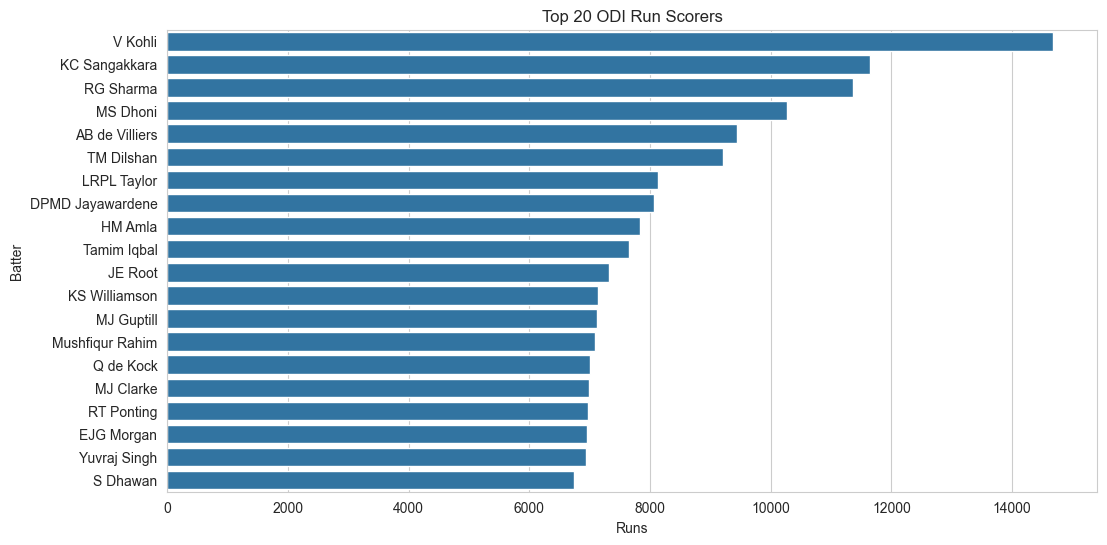

In [46]:
top_runs = batting_stats.sort_values("runs", ascending=False).head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_runs["runs"],
    y=top_runs.index
)

plt.title("Top 20 ODI Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Batter")

plt.show()

#### Most ODI Centuries

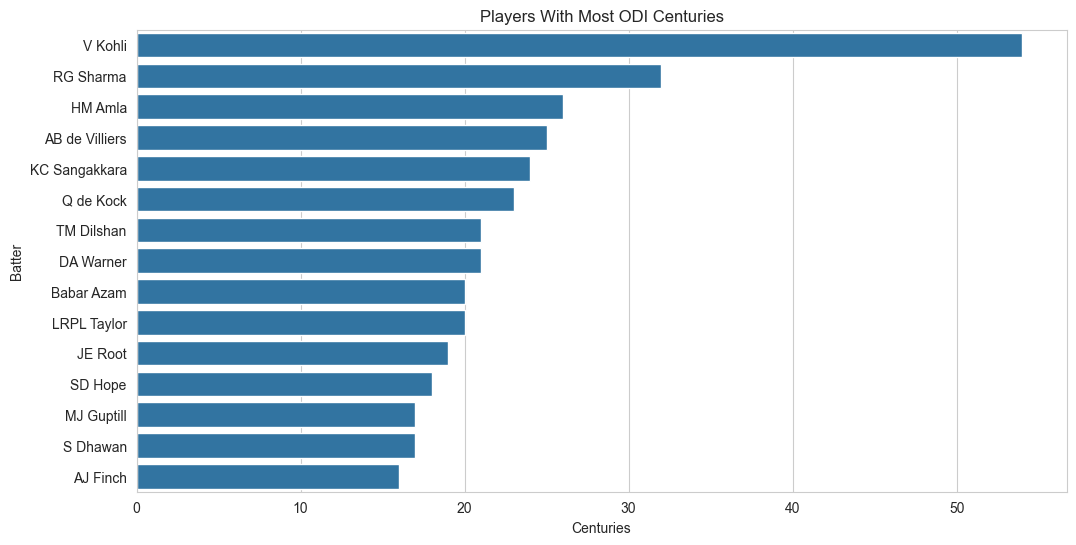

In [47]:
top_centuries = batting_stats.sort_values("100s", ascending=False).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_centuries["100s"],
    y=top_centuries.index
)

plt.title("Players With Most ODI Centuries")
plt.xlabel("Centuries")
plt.ylabel("Batter")

plt.show()

#### Strike Rate vs Batting Average

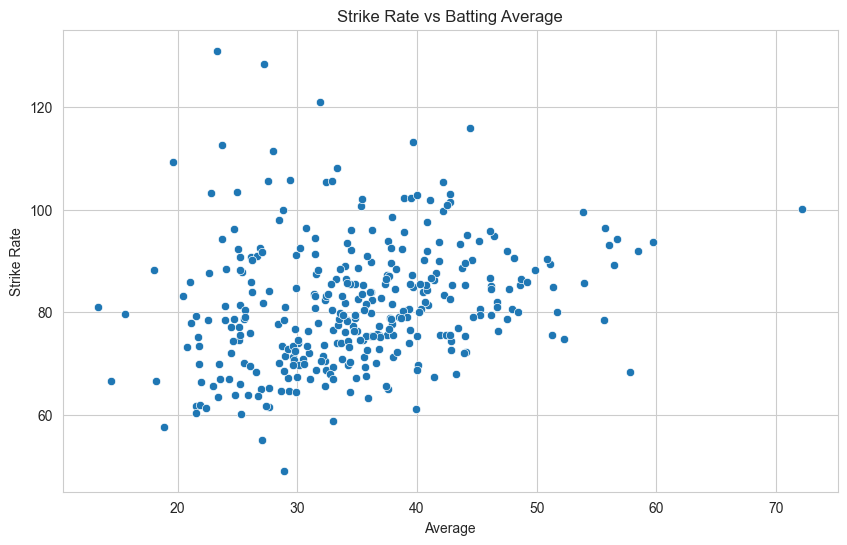

In [ ]:
plt.figure(figsize=(10,6))

elite = batting_stats[batting_stats["runs"] > 1000]

sns.scatterplot(
    data=elite,
    x="average",
    y="strike_rate"
)

plt.title("Strike Rate vs Batting Average")
plt.xlabel("Average")
plt.ylabel("Strike Rate")

plt.show()

#### Best Average (min 2000 ball faced)

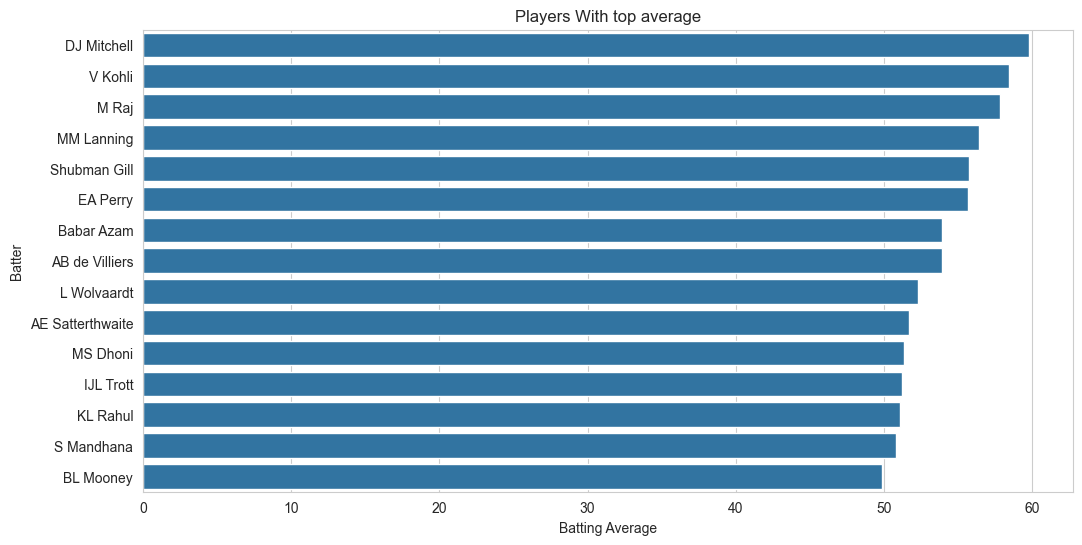

In [49]:
top_average = batting_stats[batting_stats["balls"] >= 2000]
top_average = top_average.sort_values("average", ascending=False).head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_average["average"],
    y=top_average.index
)

plt.title("Players With top average")
plt.xlabel("Batting Average")
plt.ylabel("Batter")

plt.show()

#### Best ODI Finishers

In [50]:
death_overs = df[df["over"] >= 40]

finishers = (
    death_overs.groupby("batter")
    .agg(
        runs=("runs_batter","sum"),
        balls=("ball","count")
    )
)

finishers["strike_rate"] = finishers["runs"] / finishers["balls"] * 100

top_finishers = finishers.sort_values("runs", ascending=False).head(15)

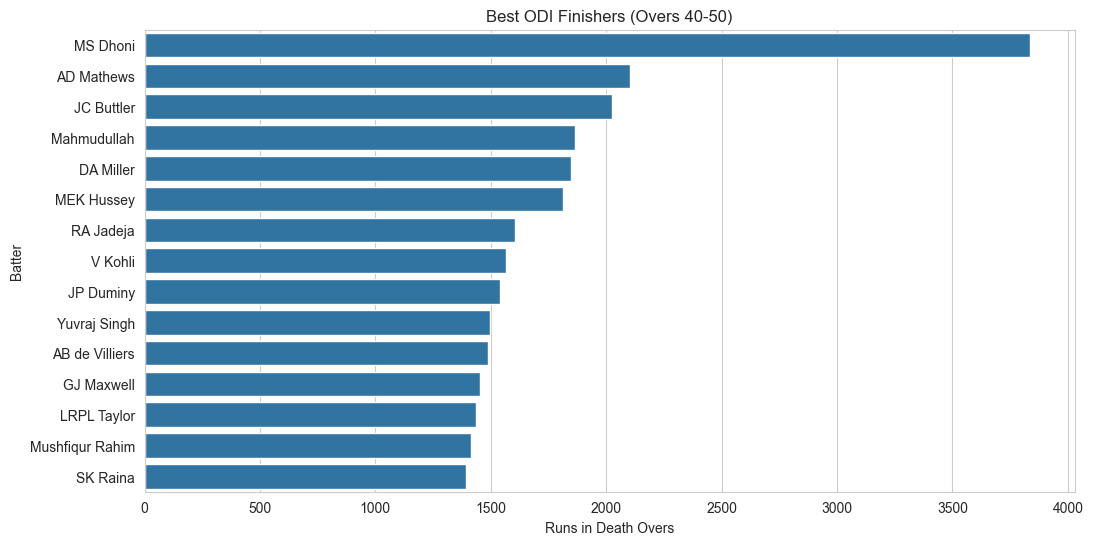

In [51]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_finishers["runs"],
    y=top_finishers.index
)

plt.title("Best ODI Finishers (Overs 40-50)")
plt.xlabel("Runs in Death Overs")
plt.ylabel("Batter")

plt.show()

#### Boundary Percentage Leaders

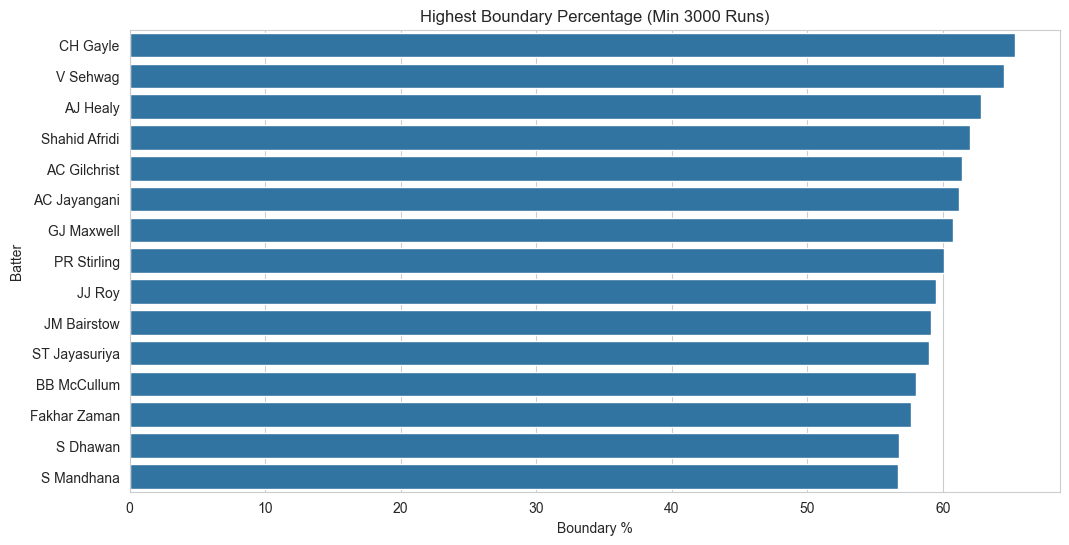

In [52]:
boundary_leaders = batting_stats[batting_stats["runs"] > 3000] \
                   .sort_values("boundary_%", ascending=False) \
                   .head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=boundary_leaders["boundary_%"],
    y=boundary_leaders.index
)

plt.title("Highest Boundary Percentage (Min 3000 Runs)")
plt.xlabel("Boundary %")
plt.ylabel("Batter")

plt.show()

#### Batting Average vs Strike Rate Quadrant Chart

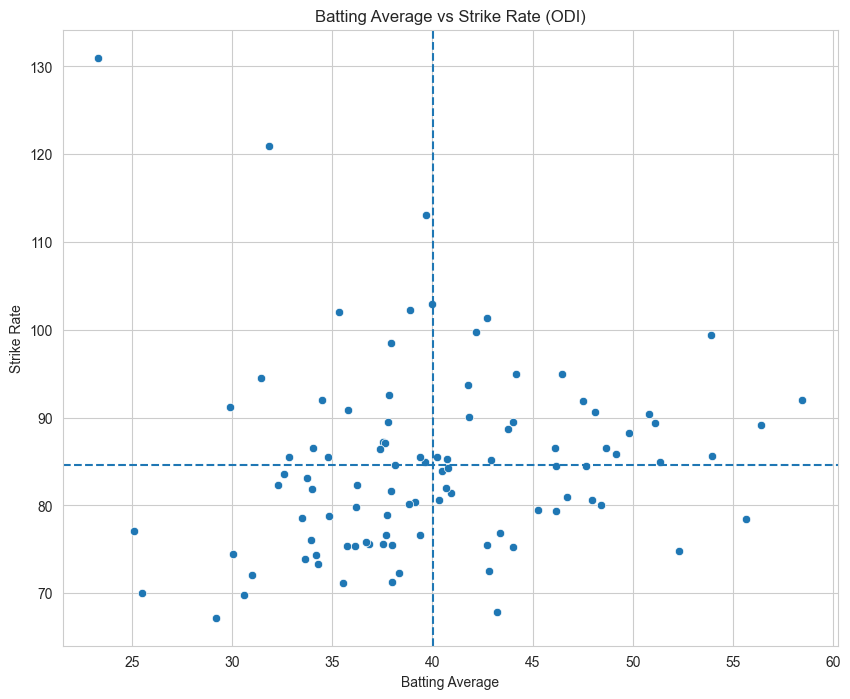

In [ ]:
elite = batting_stats[batting_stats["runs"] > 3000]

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=elite,
    x="average",
    y="strike_rate"
)

plt.axvline(elite["average"].mean(), linestyle="--")
plt.axhline(elite["strike_rate"].mean(), linestyle="--")

plt.title("Batting Average vs Strike Rate (ODI)")
plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")

plt.show()

#### `Advanced plot function`

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Batting Stats Visualization
def plot_batting_stats(batting_stats, min_runs=1000):
    """
    Create comprehensive batting visualizations
    """
    # Filter for significant batters
    batting_elite = batting_stats[batting_stats['runs'] > min_runs].copy()
    top15_batters = batting_elite.sort_values('runs', ascending=False).head(15)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Plot 1: Top run-scorers
    sns.barplot(
        data=top15_batters, 
        x='runs', 
        y=top15_batters.index if 'batter' not in top15_batters.columns else 'batter', 
        ax=axes[0,0], 
        palette='viridis'
    )
    axes[0,0].set_title('Top 15 Run Scorers', fontsize=14)
    axes[0,0].set_xlabel('Total Runs')
    
    # Plot 2: Average vs Strike Rate Quadrant
    avg_mean = batting_elite['average'].replace([np.inf, -np.inf], 0).mean()
    sr_mean = batting_elite['strike_rate'].mean()
    
    scatter = axes[0,1].scatter(
        batting_elite['average'].replace([np.inf, -np.inf], 0),
        batting_elite['strike_rate'],
        s=batting_elite['runs']/50,
        alpha=0.6,
        c=batting_elite['runs'],
        cmap='plasma'
    )
    axes[0,1].axvline(avg_mean, linestyle='--', color='gray', alpha=0.7)
    axes[0,1].axhline(sr_mean, linestyle='--', color='gray', alpha=0.7)
    axes[0,1].set_title('Batting Average vs Strike Rate', fontsize=14)
    axes[0,1].set_xlabel('Batting Average')
    axes[0,1].set_ylabel('Strike Rate')
    
    # Add quadrant labels
    axes[0,1].text(avg_mean*1.1, sr_mean*1.1, 'ELITE', fontsize=12, fontweight='bold')
    axes[0,1].text(avg_mean*0.7, sr_mean*1.1, 'Aggressive', fontsize=12)
    axes[0,1].text(avg_mean*1.1, sr_mean*0.9, 'Anchor', fontsize=12)
    axes[0,1].text(avg_mean*0.7, sr_mean*0.9, 'Weak', fontsize=12)
    
    # Plot 3: 50s and 100s distribution
    top15_batters.set_index(top15_batters.index if 'batter' not in top15_batters.columns else 'batter')[
        ['50s', '100s']
    ].plot(
        kind='barh', 
        stacked=True, 
        ax=axes[1,0], 
        color=['#3498db', '#2ecc71']
    )
    axes[1,0].set_title('Fifties vs Hundreds', fontsize=14)
    axes[1,0].set_xlabel('Count')
    axes[1,0].set_ylabel('Batter')
    axes[1,0].legend(['50s', '100s'])
    
    # Plot 4: Boundary percentage
    if 'boundary_runs' in batting_elite.columns:
        batting_elite['boundary_pct'] = (batting_elite['boundary_runs'] / batting_elite['runs'] * 100).round(2)
    else:
        batting_elite['boundary_pct'] = ((batting_elite['fours']*4 + batting_elite['sixes']*6) / 
                                         batting_elite['runs'] * 100).round(2)
    
    top15_boundary = batting_elite.nlargest(15, 'boundary_pct')
    sns.barplot(
        data=top15_boundary,
        x='boundary_pct',
        y=top15_boundary.index if 'batter' not in top15_boundary.columns else 'batter',
        ax=axes[1,1],
        palette='coolwarm'
    )
    axes[1,1].set_title('Top 15 - Boundary Percentage', fontsize=14)
    axes[1,1].set_xlabel('Boundary %')
    axes[1,1].set_ylabel('Batter')
    
    plt.tight_layout()
    plt.suptitle('Batting Statistics Analysis', fontsize=16, y=1.02)
    plt.show()

C:\Users\sk computers\AppData\Local\Temp\ipykernel_13584\3496003589.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\sk computers\AppData\Local\Temp\ipykernel_13584\3496003589.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


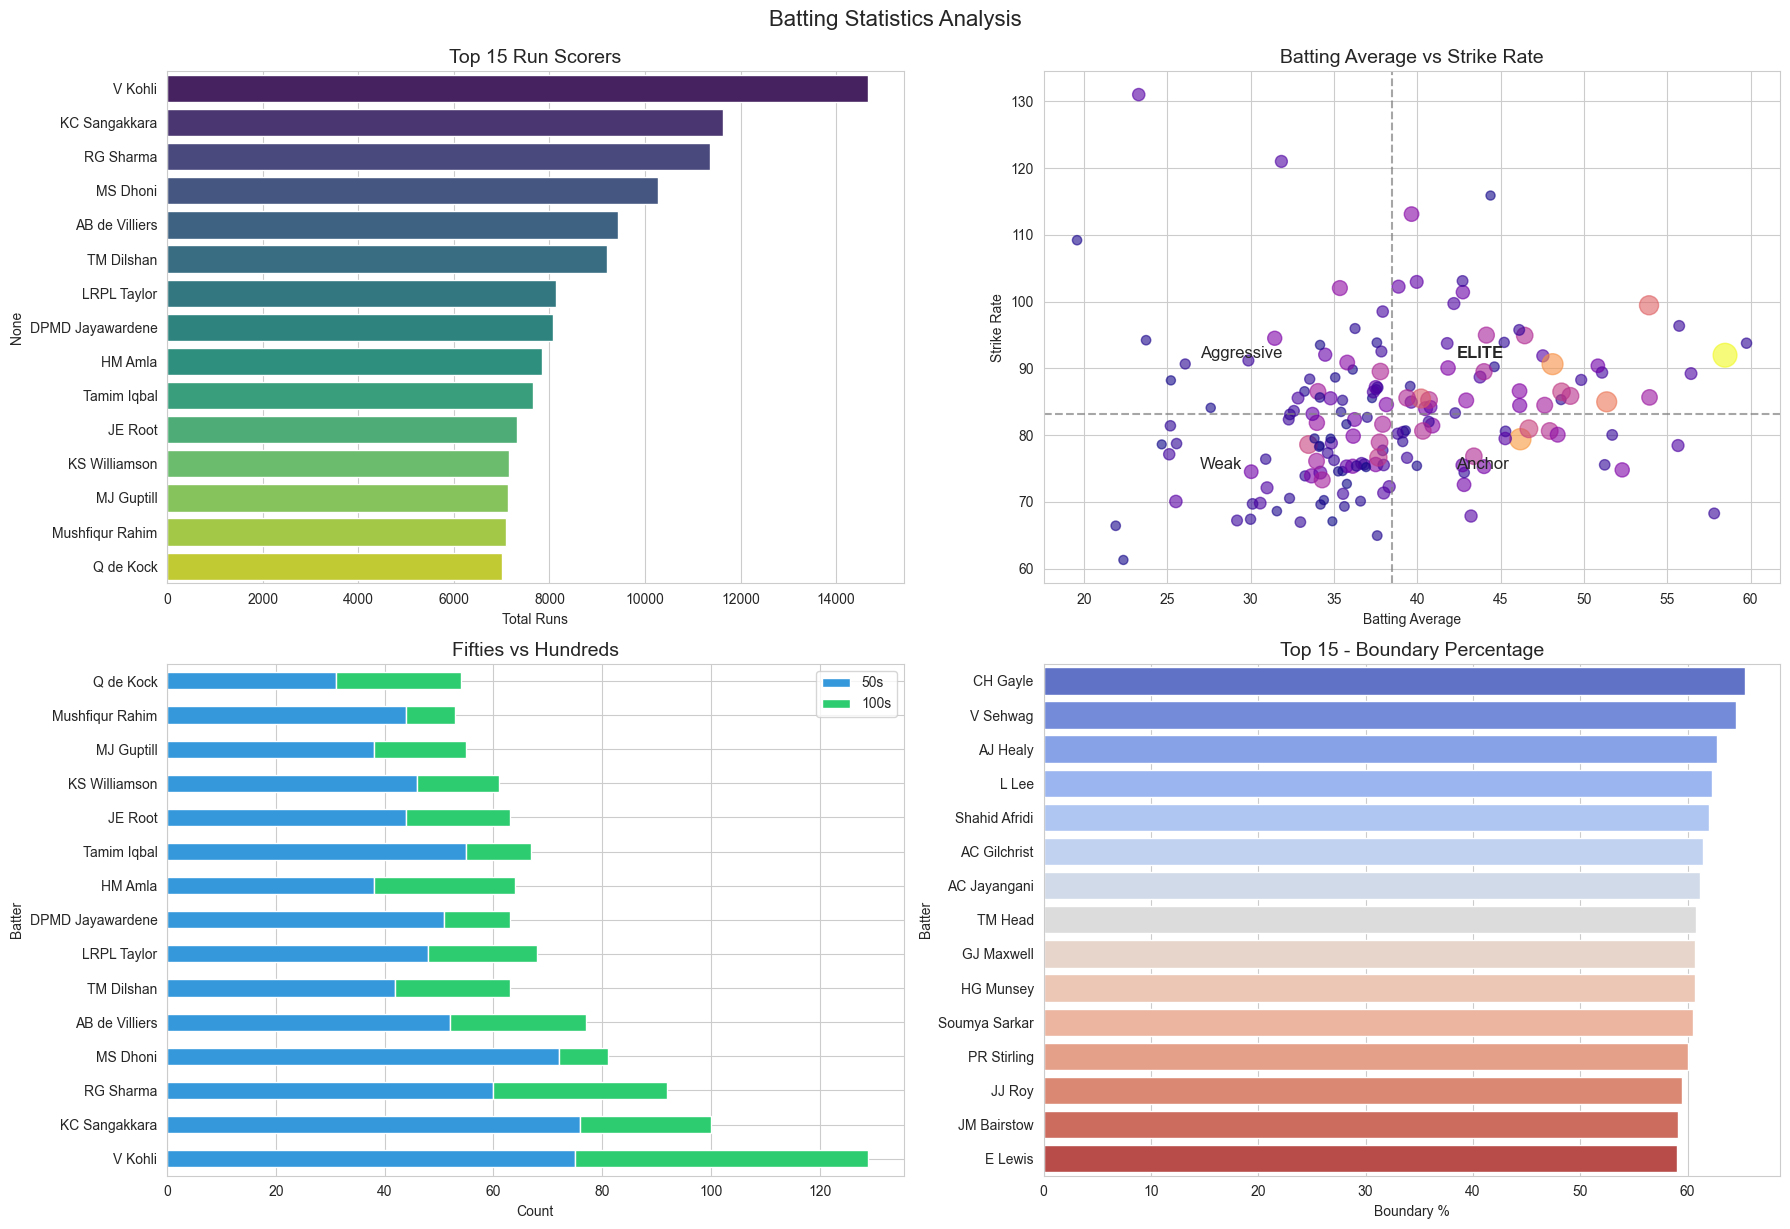

In [77]:
plot_batting_stats(batting_stats, min_runs=2000)

#### `Saving dataset`

In [64]:
batting_stats.to_csv("../data/batting_stats.csv", index=True, index_label='batter')


In [65]:
df_batting_stats = pd.read_csv(r"E:\Data analysis projects\cricket_odi_analytics\data\batting_stats.csv")

In [66]:
df_batting_stats.head()

,batter,team,matches,innings,dismisals,not_out,runs,balls,fours,sixes,50s,100s,highest_score,strike_rate,average
0,A Aitken-Drummond,Scotland,8,8,8,0,78,114,13,0,0,0,22,68.42,9.75
1,A Ashok,New Zealand,1,1,1,0,10,12,2,0,0,0,10,83.33,10.00
2,A Athanaze,West Indies,17,17,17,0,405,537,46,9,2,0,66,75.42,23.82
3,A Bagai,Canada,24,24,21,3,614,995,63,1,5,0,87,61.71,29.24
4,A Balbirnie,Ireland,83,83,79,4,2628,3557,254,34,13,8,135,73.88,33.27
